<a href="https://colab.research.google.com/github/Hamerson-jhoel/Procesamiento-de-Lengaje-Natural/blob/main/lenguaje_natural_cuaderno1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import urllib.request


In [ ]:
url ="https://raw.githubusercontent.com/juacardonahe/curso_NLP"
url +="/refs/heads/main/data/SMSSpamCollection/SMSSpamCollection"

In [ ]:
data = urllib.request.urlopen(url)

In [ ]:
lines_split = [
    line.decode().split('\t') for line in data.readlines()
]

In [ ]:
df = pd.DataFrame(lines_split, columns=["label","text"])

In [ ]:
df.sample(5, random_state=123)

,label,text
3237,ham,Aight text me when you're back at mu and I'll ...
843,ham,Our Prashanthettan's mother passed away last n...
3521,ham,No it will reach by 9 only. She telling she wi...
2123,ham,Do you know when the result.\n
738,spam,Hi. Customer Loyalty Offer:The NEW Nokia6650 M...


In [ ]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [ ]:
df["label"].value_counts()

,count
label,
ham,4827
spam,747


In [ ]:
simple_features = df.copy()

In [ ]:
simple_features["length"] = df["text"].apply(len)

In [ ]:

simple_features["number_punctuation"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in '".,;:!?()_*')
)

In [ ]:
simple_features["number_uppercase"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter!=letter.lower())
)

In [ ]:
simple_features["number_numbers"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in "0123456789")
)

In [ ]:
simple_features["number_x"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in "Xx")
)

In [ ]:
simple_features["is_spam"] = df["label"] == "spam"

In [ ]:
simple_features

,label,text,length,number_punctuation,number_uppercase,number_x,number_numbers,numjber_x,is_spam
0,ham,"Go until jurong point, crazy.. Available only ...",112,9,3,0,0,0,False
1,ham,Ok lar... Joking wif u oni...\n,30,6,2,0,0,0,False
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,156,3,10,2,25,2,True
3,ham,U dun say so early hor... U c already then say...,50,6,2,0,0,0,False
4,ham,"Nah I don't think he goes to usf, he lives aro...",62,1,2,0,0,0,False
...,...,...,...,...,...,...,...,...,...
5569,spam,This is the 2nd time we have tried 2 contact u...,161,6,9,0,21,0,True
5570,ham,Will ü b going to esplanade fr home?\n,37,1,1,0,0,0,False
5571,ham,"Pity, * was in mood for that. So...any other s...",58,7,2,0,0,0,False
5572,ham,The guy did some bitching but I acted like i'd...,126,0,2,1,0,1,False


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
stats = simple_features.groupby("label").mean(numeric_only=True)
stats

,length,number_punctuation,number_uppercase,number_x,number_numbers,numjber_x,is_spam
label,,,,,,,
ham,72.471929,3.273876,4.108763,0.148125,0.305158,0.148125,0.0
spam,139.676037,4.206158,15.469880,1.207497,15.812584,1.207497,1.0


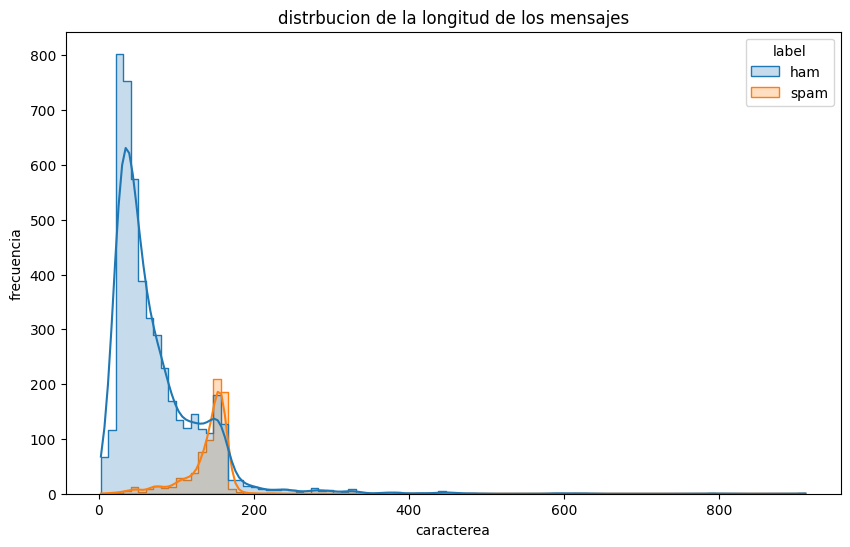

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=simple_features, x='length', hue="label", kde=True, element='step')
plt.xlabel("caracterea")
plt.ylabel("frecuencia")
plt.title("distrbucion de la longitud de los mensajes")
plt.show()

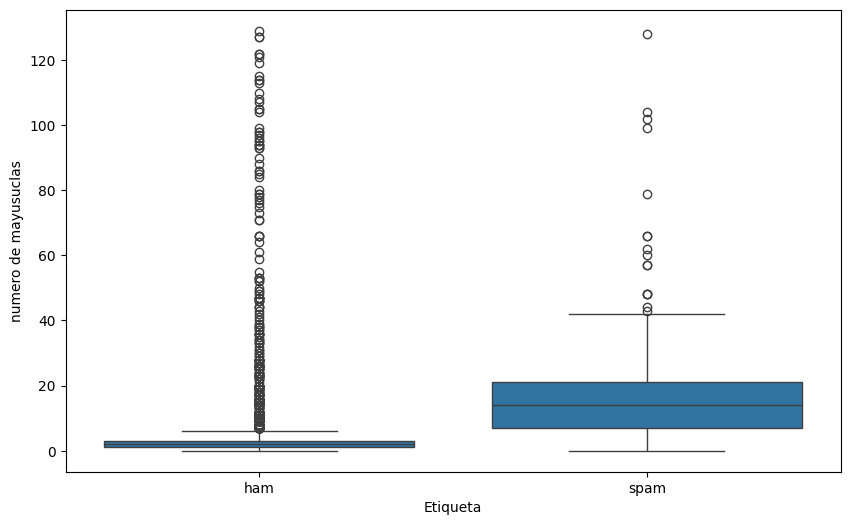

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=simple_features, x='label', y='number_uppercase')
plt.xlabel("Etiqueta")
plt.ylabel("numero de mayusuclas")
plt.show()


In [ ]:
import re

In [ ]:
def basic_normalize(text):
  text = text.lower() #convertir todos los carecteres en minusculas
  text = re.sub(r'[^a-z0-9\s]','',text) #dejar solo letras o numeros
  tokens = text.split() #separar por palabras
  return tokens

In [ ]:
simple_features["tokens_basic"]= simple_features["text"].apply(
    basic_normalize)


In [ ]:
simple_features[["text","tokens_basic"]]

,text,tokens_basic
0,"Go until jurong point, crazy.. Available only ...","[go, until, jurong, point, crazy, available, o..."
1,Ok lar... Joking wif u oni...\n,"[ok, lar, joking, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,"Nah I don't think he goes to usf, he lives aro...","[nah, i, dont, think, he, goes, to, usf, he, l..."
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,..."
5570,Will ü b going to esplanade fr home?\n,"[will, b, going, to, esplanade, fr, home]"
5571,"Pity, * was in mood for that. So...any other s...","[pity, was, in, mood, for, that, soany, other,..."
5572,The guy did some bitching but I acted like i'd...,"[the, guy, did, some, bitching, but, i, acted,..."


In [ ]:
STOPWORDS ={"i","me","my","myself","we","our","ours",
            "ourselves","you","your","yours", "he", "him",
            "his", "she", "her", "it","its", "they", "them",
            "to", "at", "by", "for", "the"}

In [ ]:
def remove_noise(tokens):
  clean_tokens = [t for t in tokens if t not in STOPWORDS and not t.isdigit()]
  return clean_tokens

In [ ]:
simple_features["tokens_clean"] = simple_features["tokens_basic"].apply(remove_noise)

In [ ]:
simple_features["tokens_clean"]

,tokens_clean
0,"[go, until, jurong, point, crazy, available, o..."
1,"[ok, lar, joking, wif, u, oni]"
2,"[free, entry, in, a, wkly, comp, win, fa, cup,..."
3,"[u, dun, say, so, early, hor, u, c, already, t..."
4,"[nah, dont, think, goes, usf, lives, around, h..."
...,...
5569,"[this, is, 2nd, time, have, tried, contact, u,..."
5570,"[will, b, going, esplanade, fr, home]"
5571,"[pity, was, in, mood, that, soany, other, sugg..."
5572,"[guy, did, some, bitching, but, acted, like, i..."


In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
def lemmatize_spacy(tokens):
  doc = nlp(" ".join(tokens))
  return [token.lemma_ for token in doc]

In [ ]:
simple_features["lemmatized"]= simple_features["tokens_clean"].apply(
    lemmatize_spacy
)

In [ ]:
simple_features[["tokens_clean", "lemmatized"]]

,tokens_clean,lemmatized
0,"[go, until, jurong, point, crazy, available, o...","[go, until, jurong, point, crazy, available, o..."
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, in, a, wkly, comp, win, fa, cup,...","[free, entry, in, a, wkly, comp, win, fa, cup,..."
3,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, so, early, hor, u, c, already, t..."
4,"[nah, dont, think, goes, usf, lives, around, h...","[nah, do, not, think, go, usf, life, around, h..."
...,...,...
5569,"[this, is, 2nd, time, have, tried, contact, u,...","[this, be, 2nd, time, have, try, contact, u, u..."
5570,"[will, b, going, esplanade, fr, home]","[will, b, go, esplanade, fr, home]"
5571,"[pity, was, in, mood, that, soany, other, sugg...","[pity, be, in, mood, that, soany, other, sugge..."
5572,"[guy, did, some, bitching, but, acted, like, i...","[guy, do, some, bitching, but, act, like, I, d..."


In [ ]:
def pos_tag_spacy(tokens):
  doc = nlp(" ".join(tokens))
  return[(token.text, token.pos_) for token in doc]

In [ ]:
simple_features["pog_tags"] = simple_features["tokens_clean"].apply(pos_tag_spacy)

In [ ]:
simple_features[["tokens_clean","pog_tags"]]

,tokens_clean,pog_tags
0,"[go, until, jurong, point, crazy, available, o...","[(go, VERB), (until, SCONJ), (jurong, PROPN), ..."
1,"[ok, lar, joking, wif, u, oni]","[(ok, INTJ), (lar, ADJ), (joking, NOUN), (wif,..."
2,"[free, entry, in, a, wkly, comp, win, fa, cup,...","[(free, ADJ), (entry, NOUN), (in, ADP), (a, DE..."
3,"[u, dun, say, so, early, hor, u, c, already, t...","[(u, PRON), (dun, PROPN), (say, VERB), (so, AD..."
4,"[nah, dont, think, goes, usf, lives, around, h...","[(nah, INTJ), (do, AUX), (nt, PART), (think, V..."
...,...,...
5569,"[this, is, 2nd, time, have, tried, contact, u,...","[(this, PRON), (is, AUX), (2nd, ADJ), (time, N..."
5570,"[will, b, going, esplanade, fr, home]","[(will, AUX), (b, ADP), (going, VERB), (esplan..."
5571,"[pity, was, in, mood, that, soany, other, sugg...","[(pity, NOUN), (was, AUX), (in, ADP), (mood, N..."
5572,"[guy, did, some, bitching, but, acted, like, i...","[(guy, NOUN), (did, VERB), (some, DET), (bitch..."


In [ ]:
def full_nlp_pipeline(text):
  text = text.lower()
  text = re.sub(r'[^a-z0-9\s]', '', text)

  doc = nlp(text)

  clean_lemmas=[token.lemma_ for token in doc if token.is_stop and not token.like_num and len (token.text)>1]

  return clean_lemmas

In [ ]:
df["final_tokens"] = df["text"].apply(full_nlp_pipeline)
df[["text","final_tokens"]]

,text,final_tokens
0,"Go until jurong point, crazy.. Available only ...","[go, until, only, in, there]"
1,Ok lar... Joking wif u oni...\n,[]
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[in, to, may, to, to]"
3,U dun say so early hor... U c already then say...,"[say, so, already, then, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[do, he, to, he, around, here, though]"
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,"[this, be, the, we, have, have, the, be, call,..."
5570,Will ü b going to esplanade fr home?\n,"[will, to]"
5571,"Pity, * was in mood for that. So...any other s...","[be, in, for, that, other]"
5572,The guy did some bitching but I acted like i'd...,"[the, do, some, but, be, in, something, else, ..."


Instrucciones:

1. Filtrar por POS:Utilizando la columna pos_tags(o creando una funcion nueva con Spacy), extrae unicamente los verbos (VERB) y los adjetivos (ADJ) de cada mensaje

2. Analisis de frecuencia

- Crea una lista de todos los verbos encontrados en mensajes

In [ ]:
def extract_verbs_adjs(pos_tags):
  return [word for word, tag in pos_tags if tag in ['VERB', 'ADJ']]

simple_features['verbs_adjs'] = simple_features['pog_tags'].apply(extract_verbs_adjs)

In [ ]:
simple_features[['text', 'verbs_adjs']]

,text,verbs_adjs
0,"Go until jurong point, crazy.. Available only ...","[go, available, great, got]"
1,Ok lar... Joking wif u oni...\n,[lar]
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, wkly, final, text, receive, txt, apply]"
3,U dun say so early hor... U c already then say...,"[say, early, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[think, goes, usf]"
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,"[2nd, tried, won, easy]"
5570,Will ü b going to esplanade fr home?\n,[going]
5571,"Pity, * was in mood for that. So...any other s...","[soany, other]"
5572,The guy did some bitching but I acted like i'd...,"[did, acted, interested, buying, next, gave, f..."


In [ ]:
from collections import Counter


spam_verbs = []
for tags in simple_features[simple_features['label']== 'spam']['pog_tags']:
  verbs = [word for word, tag in tags if tag == 'VERB']
  spam_verbs.extend(verbs)

print(Counter(spam_verbs).most_common(10))

[('call', 182), ('won', 73), ('get', 70), ('stop', 65), ('txt', 59), ('send', 58), ('guaranteed', 50), ('win', 45), ('have', 40), ('claim', 39)]


In [ ]:
from collections import Counter

# Get all verbs and adjectives for spam messages
spam_verbs_adjs = []
for va_list in simple_features[simple_features['label'] == 'spam']['verbs_adjs']:
  spam_verbs_adjs.extend(va_list)

# Get the 10 most common verbs and adjectives for spam
print("10 most common verbs/adjectives in spam messages:")
print(Counter(spam_verbs_adjs).most_common(10))

10 most common verbs/adjectives in spam messages:
[('free', 204), ('call', 182), ('won', 73), ('get', 70), ('new', 67), ('stop', 65), ('mobile', 61), ('txt', 59), ('send', 58), ('guaranteed', 50)]


In [ ]:
from collections import Counter

# Get all verbs and adjectives for ham messages
ham_verbs_adjs = []
for va_list in simple_features[simple_features['label'] == 'ham']['verbs_adjs']:
  ham_verbs_adjs.extend(va_list)

# Get the 10 most common verbs and adjectives for ham
print("10 most common verbs/adjectives in ham messages:")
print(Counter(ham_verbs_adjs).most_common(10))

10 most common verbs/adjectives in ham messages:
[('get', 281), ('m', 253), ('have', 250), ('go', 242), ('s', 235), ('come', 221), ('good', 218), ('know', 216), ('got', 215), ('ill', 166)]


In [ ]:
ham_verbs = []
for tags in simple_features[simple_features['label'] == 'ham']['pog_tags']:
  verbs = [word for word, tag in tags if tag == 'VERB']
  ham_verbs.extend(verbs)

print(Counter(ham_verbs).most_common(10))

[('get', 281), ('m', 253), ('have', 250), ('go', 242), ('s', 235), ('come', 221), ('got', 215), ('know', 214), ('going', 161), ('want', 137)]
